# Exploratory Data Analysis (EDA) — Двухстадийный классификатор трафика

**Цель анализа:** 1. Оценить распределение целевой переменной (`Label`) и обосновать необходимость двухстадийного обучения.
2. Проверить баланс классов для настройки функции взвешивания (`compute_class_weights`).
3. Изучить структуру признаков после финальной очистки.

In [34]:
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def get_project_root(marker_files=[".git", "pyproject.toml", "README.md"]) -> Path:
    """Динамически ищет корень проекта, поднимаясь вверх от текущего файла/папки."""
    # В Jupyter __file__ не работает, поэтому берем Path(".").resolve() (текущую папку ноутбука)
    current_dir = Path(".").resolve()
    for parent in [current_dir, *current_dir.parents]:
        if any((parent / marker).exists() for marker in marker_files):
            return parent
    raise FileNotFoundError(f"Корень проекта не найден. Маркеры: {marker_files}")

def load_config() -> dict:
    # 1. Сначала находим корень проекта (автоматически выйдет из папки notebooks)
    root_dir = get_project_root()
    # 2. Строим абсолютный чистый путь к конфигу
    config_path = root_dir / "config.yaml"
    
    with open(config_path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

# Теперь запускаем без всяких ручных путей!
CONFIG = load_config()
print("Конфиг загружен.")

Конфиг загружен.


In [35]:
base_dir = Path(".").resolve().parent
data_path = base_dir / CONFIG["data"]["rel_path"]

print(f"Загрузка данных из: {data_path}")
df = pd.read_parquet(data_path)
print(f"Размерность датасета: {df.shape[0]} строк, {df.shape[1]} колонок.")

Загрузка данных из: C:\Users\lifie\CICIDS2017-XGB-H\data\processed\stage1_cleaned.parquet
Размерность датасета: 2522362 строк, 78 колонок.


## ЭТАП 1: Анализ целевой переменной и дисбаланса классов

Посмотрим на распределение исходных меток `Label`, чтобы наглядно увидеть проблему "редких атак".

=== Исходное распределение классов ===
                            Количество   Доля (%)
Label                                            
BENIGN                         2096484  83.115905
DoS Hulk                        172849   6.852664
DDoS                            128016   5.075243
PortScan                         90819   3.600554
DoS GoldenEye                    10286   0.407792
FTP-Patator                       5933   0.235216
DoS slowloris                     5385   0.213490
DoS Slowhttptest                  5228   0.207266
SSH-Patator                       3219   0.127618
Bot                               1953   0.077427
Web Attack - Brute Force          1470   0.058279
Web Attack - XSS                   652   0.025849
Infiltration                        36   0.001427
Web Attack - Sql Injection          21   0.000833
Heartbleed                          11   0.000436


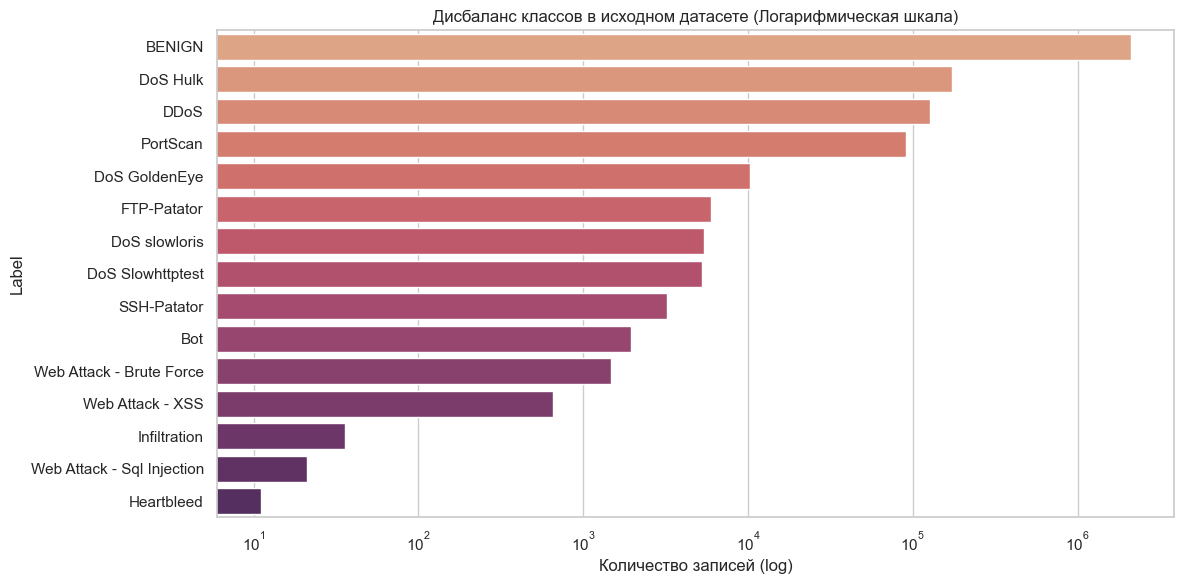

In [36]:
label_counts = df["Label"].value_counts()
label_probs = df["Label"].value_counts(normalize=True) * 100

# Вывод в виде таблицы
dist_df = pd.DataFrame({"Количество": label_counts, "Доля (%)": label_probs})
print("=== Исходное распределение классов ===")
print(dist_df)

# Визуализация дисбаланса
ax = sns.barplot(x=label_counts.values, y=label_counts.index, palette="flare", hue=label_counts.index, legend=False)
plt.title("Дисбаланс классов в исходном датасете (Логарифмическая шкала)")
plt.xscale("log")  # Используем log-шкалу, так как разница между классами может быть в тысячи раз
plt.xlabel("Количество записей (log)")
plt.tight_layout()
plt.show()

## ЭТАП 2: Обоснование двухстадийной архитектуры

Теперь симулируем маппинг для **Stage 1**, как это делается в `train.py`, чтобы проверить распределение укрупненных классов (BENIGN, Web_Bot, Other_Attack).

=== Распределение классов для Stage 1 ===
Stage1_Label
BENIGN          83.115905
Other_Attack    16.721708
Web_Bot          0.162387
Name: proportion, dtype: float64


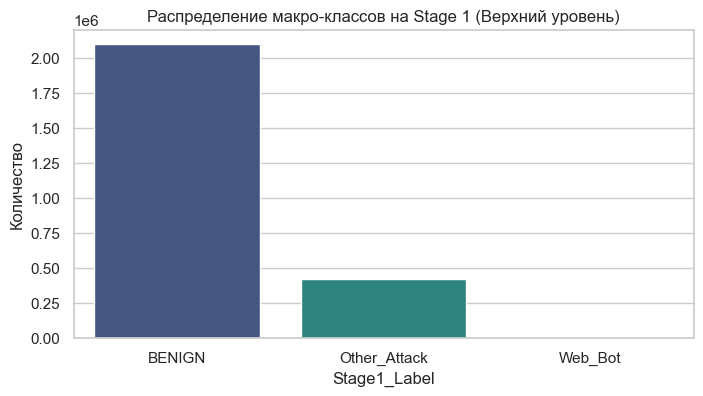


=== Доля данных, уходящих на Stage 2: 16.72% ===


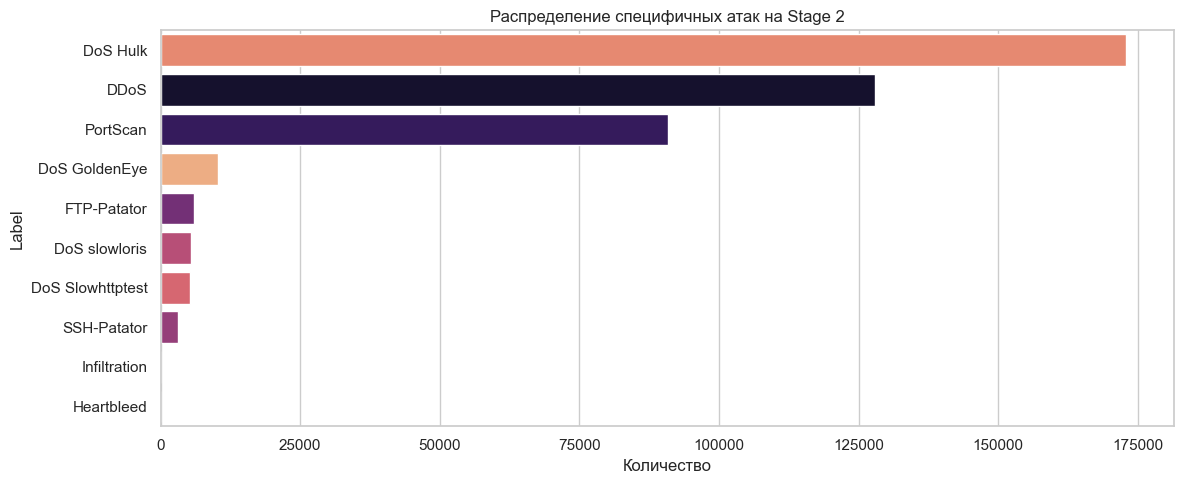

In [37]:
# Применяем маппинг из конфига
df['Stage1_Label'] = df['Label'].map(CONFIG["mappings"]["label1_map"]).fillna('Other_Attack')

# Смотрим распределение на Первой Стадии
stage1_counts = df['Stage1_Label'].value_counts()
print("=== Распределение классов для Stage 1 ===")
print(df['Stage1_Label'].value_counts(normalize=True) * 100)

# График для Stage 1
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Stage1_Label', palette="viridis", hue='Stage1_Label', legend=False)
plt.title("Распределение макро-классов на Stage 1 (Верхний уровень)")
plt.ylabel("Количество")
plt.show()

# Смотрим распределение внутри Stage 2 (только специфичные атаки)
label_stage2 = CONFIG["mappings"]["label_stage2"]
df_s2 = df[df["Label"].isin(label_stage2)]

print(f"\n=== Доля данных, уходящих на Stage 2: {len(df_s2) / len(df) * 100:.2f}% ===")

plt.figure(figsize=(12, 5))
sns.countplot(data=df_s2, y='Label', palette="magma", order=df_s2['Label'].value_counts().index, hue='Label', legend=False)
plt.title("Распределение специфичных атак на Stage 2")
plt.xlabel("Количество")
plt.tight_layout()
plt.show()

## ЭТАП 3: Анализ числовых признаков (Features)

Проверим типы данных, наличие бесконечных значений (`inf`), которые могут возникать при делении в сетевом трафике (например, `Bytes/sec`), и базовую описательную статистику.

In [38]:
feature_cols = [c for c in df.columns if c not in {"Label", "Stage1_Label"}]
print(f"Всего признаков для обучения: {len(feature_cols)}")

# Проверка на типы данных
types = df[feature_cols].dtypes.value_counts()
print(f"\nТипы данных признаков:\n{types}")

# Проверка на наличие inf значений (XGBoost их не любит, если они не обработаны)
inf_counts = np.isinf(df[feature_cols]).sum()
features_with_inf = inf_counts[inf_counts > 0]
if not features_with_inf.empty:
    print(f"\nВнимание! Найдены inf-значения в колонках:\n{features_with_inf}")
else:
    print("\nОтлично: Бесконечных значений (inf) в признаках не обнаружено.")

# Выведем топ-5 признаков с наибольшей стандартной девиацией (вариативностью)
stats = df[feature_cols].describe().T
print("\n=== Топ-5 самых вариативных признаков ===")
print(stats.sort_values(by="std", ascending=False)[["min", "mean", "max", "std"]].head(5))

Всего признаков для обучения: 77

Типы данных признаков:
int64      53
float64    24
Name: count, dtype: int64

Отлично: Бесконечных значений (inf) в признаках не обнаружено.

=== Топ-5 самых вариативных признаков ===
               min          mean           max           std
Flow Duration  0.0  1.658132e+07  1.200000e+08  3.522426e+07
Fwd IAT Total  0.0  1.624176e+07  1.200000e+08  3.515781e+07
Bwd IAT Total  0.0  1.110336e+07  1.200000e+08  3.022113e+07
Flow Bytes/s   0.0  1.410302e+06  2.071000e+09  2.656176e+07
Fwd IAT Max    0.0  1.013665e+07  1.200000e+08  2.575975e+07


## 📊 Итоговые выводы по результатам EDA

### 1. Масштаб и структура данных
* **Объем выборки:** Обработано **2 522 422** записи и **77** обучающих признаков. Это репрезентативный объем для построения промышленных систем обнаружения вторжений (IDS).
* **Типы данных:** Все фичи приведены к числовым форматам (`int64` — 53, `float64` — 24), пропуски отсутствуют, бесконечные значения (`inf`) не обнаружены. Данные технически готовы к подаче в деревья решений.

### 2. Математическое обоснование двухстадийной (Two-Stage) архитектуры
Цифры наглядно доказывают, что разделение пайплайна на две стадии — это критически важное архитектурное решение для продакшна:
* **Stage 1 (Фильтрация):** Модель первого уровня решает простую макро-задачу, разделяя безопасный трафик (**BENIGN — 83.12%**), веб-ботов (**Web_Bot — 0.16%**) и остальные атаки (**Other_Attack — 16.72%**). 
* **Экономия ресурсов в Проде (Inference Optimization):** Благодаря такому подходу, тяжелая и ресурсоемкая модель **Stage 2** (мультиклассификация 10 типов атак) будет обрабатывать **всего 16.72% от общего трафика**. 83.28% пакетов будут мгновенно классифицироваться на первом этапе, что колоссально снижает нагрузку на CPU/GPU сервера классификации.

### 3. Экстремальный дисбаланс классов и стратегия борьбы с ним
В исходных данных наблюдается жесткий дисбаланс, граничащий с аномалиями:
* Безопасный трафик доминирует (**83.12%**).
* Присутствуют «исчезающе редкие» классы атак, например: `Infiltration` (36 строк, 0.0014%), `SQL Injection` (21 строка, 0.0008%), `Heartbleed` (всего 11 строк на 2.5 млн, 0.0004%).
* **Решение:** Обучать модели "в лоб" на таких данных нельзя — они просто проигнорируют редкие атаки. Использование `compute_class_weights` с динамическим расчетом весов через квадратный корень и последующим клиппингом (`stage1_clip_weight: 50.0`, `stage2_clip_weight: 1000.0`) математически необходимо, чтобы заставить XGBoost замечать единичные сэмплы критических угроз.

### 4. Инженерный инсайт: Вариативность и артефакты в признаках
Анализ топ-5 самых вариативных признаков (`Flow Duration`, `Fwd IAT Total` и др.) выявил важную особенность:
* Значения стандартного отклонения (`std`) достигают порядка $3.5 \times 10^7$, что говорит о колоссальном разбросе метрик сетевого трафика во времени. Градиентный бустинг (XGBoost) устойчив к таким масштабам, так как строит сплиты, а не считает расстояния.